In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import torch
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../../")
import InfoGlobe
from InfoGlobe.metrics import fisher_rao_dis_matrix
from InfoGlobe.utils import get_knn
from InfoGlobe.filter import global_variance_vary, greedy_var

/home/wangcheng/anaconda3/envs/MarkovMF/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
adata = sc.read_h5ad('../../../pancreas_acinar.h5ad')
adata.layers['counts'] = adata.X.copy()

In [6]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)

adata = adata[:, adata.var['highly_variable']].copy()
adata.X = adata.layers['counts'].copy()

In [7]:
P = adata.X.copy()
P = P / P.sum(axis=1, keepdims=True)
P_gd = P.T

In [8]:
n, m = P_gd.shape
k = 80

In [ ]:
model = InfoGlobe.infoglobe.GlobeEmbedding(A = [n,k], Q = [k,m], c=1)
model.fit(torch.Tensor(P_gd), max_iter=30000)

  0%|          | 0/30000 [00:00<?, ?it/s]/home/wangcheng/projects/InfoGlobe_ICML/benchmark/pancreas/../../InfoGlobe/infoglobe.py:201: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/home/wangcheng/projects/InfoGlobe_ICML/benchmark/pancreas/../../InfoGlobe/infoglobe.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 30000/30000 [15:05<00:00, 33.14it/s]


30000

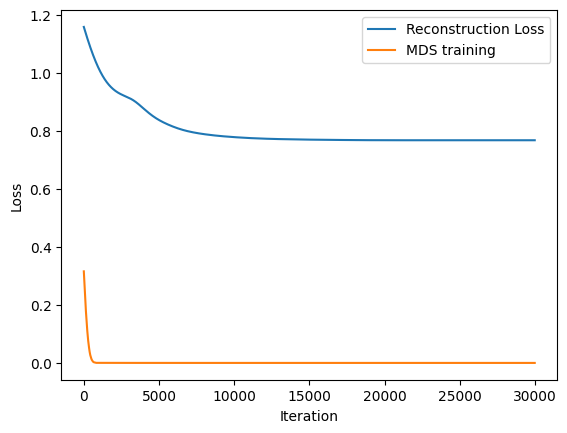

In [ ]:
x = x = [i*10 for i in range(len(MMF.loss1))] 

plt.plot(x, model.loss1, label='Reconstruction Loss')
plt.plot(x, model.loss2, label='MDS training')
# plt.yscale('log')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
adata.obsm['markov_embedding'] = model.Q.detach().cpu().numpy().T
adata.varm['markov_kernel'] = model.A.detach().cpu().numpy()
# adata.obsm['markov_embedding'] = embedding

In [20]:
# fisher_dis_mat = fisher_rao_dis_matrix(MMF.Q)
fisher_dis_mat = fisher_rao_dis_matrix(torch.tensor(adata.obsm['markov_embedding'].T))
dis_mat, knn_mat = get_knn(fisher_dis_mat, k=30)

adata.obsp['connectivities'] = knn_mat
adata.obsp['distances'] = dis_mat

In [21]:
adata.uns['neighbors'] = {
    'params': {
        'n_neighbors': 30,
        'method': 'umap',
        'metric': 'fisher_rao',
        # 可以添加其他 Scanpy 期望的参数，如：
        'use_rep': 'markov_embedding', # 告诉 UMAP/Leiden 使用哪个数据表示来计算邻居 (即使您是预计算的)
    },
    
    # 保持不变：指向 obsp 中的矩阵
    'connectivities_key': 'connectivities',
    'distances_key': 'distances',
}

sc.tl.umap(adata, init_pos='random')